# Лабораторная работа №1
### Тема: Обработка признаков (часть 1)
* **Выполнил:** Бумагин П. В.
* **Группа:** ИУ5-22М 
* **Преподаватель:** Гапанюк Ю. Е.

---

### 1. Описание задания
**Цель работы:** Изучение продвинутых способов предварительной обработки данных для дальнейшего формирования моделей машинного обучения.

**Задачи:**
1. Выбрать набор данных (датасет), содержащий категориальные и числовые признаки и пропуски в данных.
2. Устранить пропуски в данных (для числовых и категориальных признаков).
3. Выполнить кодирование категориальных признаков.
4. Выполнить нормализацию числовых признаков.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, PowerTransformer

# Настройка стиля графиков
sns.set_theme(style="whitegrid")

# Загружаем датасет о пингвинах архипелага Палмер
df = sns.load_dataset('penguins')

print(f"Размерность исходного датасета: {df.shape}")
print("\nПервые 5 строк датасета:")
print(df.head())

Размерность исходного датасета: (344, 7)

Первые 5 строк датасета:
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  


### Анализ пропусков в данных
Определим, в каких колонках нашего датасета присутствуют пропущенные значения (`NaN`).

Количество пропусков по колонкам:
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


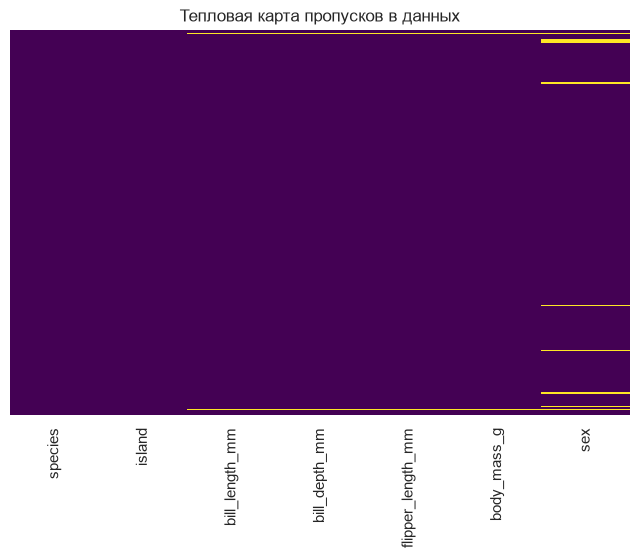

In [2]:
# Вычисляем количество пропусков для каждого признака
missing_info = df.isnull().sum()
print("Количество пропусков по колонкам:")
print(missing_info[missing_info > 0])

# Визуализируем пропуски с помощью тепловой карты
plt.figure(figsize=(8, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Тепловая карта пропусков в данных')
plt.show()

###  Решение задачи 1: Устранение пропусков в данных

####  Заполнение пропусков в числовых признаках
Для числовых признаков (например, `bill_length_mm` — длина клюва) мы применим заполнение медианой, так как медиана устойчива к возможным выбросам.

In [3]:
# Создаем импутер для заполнения медианой
num_imputer = SimpleImputer(strategy='median')

# Колонки с числовыми пропусками
num_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

# Заполняем пропуски
df[num_cols] = num_imputer.fit_transform(df[num_cols])

print("Число пропусков в числовых признаках после импутации:")
print(df[num_cols].isnull().sum())

Число пропусков в числовых признаках после импутации:
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
dtype: int64


####  Заполнение пропусков в категориальных признаках
У нас есть пропуски в категориальной колонке `sex` (пол пингвина). Заполним их наиболее часто встречающимся значением (модой).

In [4]:
# Создаем импутер для заполнения наиболее частым значением (модой)
cat_imputer = SimpleImputer(strategy='most_frequent')

# Заполняем пропуски в колонке 'sex'
df[['sex']] = cat_imputer.fit_transform(df[['sex']])

print("Общее число пропусков в датасете после обработки:")
print(df.isnull().sum())

Общее число пропусков в датасете после обработки:
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64


### Решение задачи 2: Кодирование категориальных признаков

Для того чтобы модели машинного обучения могли работать с текстовыми категориями, их нужно перевести в числовой вид. Применим два популярных метода кодирования:

1. **One-Hot Encoding (OHE):** Подходит для номинальных признаков без строгого порядка (например, признак `island` — остров).
2. **Label Encoding:** Кодирование целыми числами (подходит для бинарных признаков, таких как `sex`).

In [5]:
# 1. Применяем Label Encoding к бинарному признаку 'sex'
le = LabelEncoder()
df['sex_encoded'] = le.fit_transform(df['sex'])
print("Соответствие классов после Label Encoding (sex):")
for index, class_name in enumerate(le.classes_):
    print(f"  {class_name} -> {index}")

# 2. Применяем One-Hot Encoding к номинальному признаку 'island'
ohe = OneHotEncoder(sparse_output=False, drop='first') # drop='first' помогает избежать мультиколлинеарности
island_ohe = ohe.fit_transform(df[['island']])

# Создаем новые колонки на основе категорий
ohe_cols = [f"island_{cat}" for cat in ohe.categories_[0][1:]]
df_ohe = pd.DataFrame(island_ohe, columns=ohe_cols)

# Объединяем полученные колонки с основным датафреймом
df = pd.concat([df, df_ohe], axis=1)

print("\nРезультат кодирования признаков (первые 5 строк):")
print(df[['island'] + ohe_cols + ['sex', 'sex_encoded']].head())

Соответствие классов после Label Encoding (sex):
  Female -> 0
  Male -> 1

Результат кодирования признаков (первые 5 строк):
      island  island_Dream  island_Torgersen     sex  sex_encoded
0  Torgersen           0.0               1.0    Male            1
1  Torgersen           0.0               1.0  Female            0
2  Torgersen           0.0               1.0  Female            0
3  Torgersen           0.0               1.0    Male            1
4  Torgersen           0.0               1.0  Female            0


### Решение задачи 3: Нормализация числовых признаков

Нормализация применяется для того, чтобы привести распределение числового признака к виду, максимально близкому к нормальному (гауссовскому) распределению. 

Будем нормализовать признак `body_mass_g` (масса тела пингвина). Применим два популярных преобразования:
1. **Логарифмическое преобразование** ($np.log$).
2. **Преобразование Йео-Джонсона (Yeo-Johnson)** — мощный степенной метод, оптимизирующий параметры нормальности автоматически.

In [6]:
# 1. Логарифмирование
df['body_mass_log'] = np.log(df['body_mass_g'])

# 2. Преобразование Йео-Джонсона (используем PowerTransformer)
pt = PowerTransformer(method='yeo-johnson')
df['body_mass_yeo'] = pt.fit_transform(df[['body_mass_g']])

print("Описательные статистики признака до и после нормализации:")
print(df[['body_mass_g', 'body_mass_log', 'body_mass_yeo']].describe())

Описательные статистики признака до и после нормализации:
       body_mass_g  body_mass_log  body_mass_yeo
count   344.000000     344.000000   3.440000e+02
mean   4200.872093       8.325386   9.679079e-14
std     799.696532       0.187460   1.001457e+00
min    2700.000000       7.901007  -2.474441e+00
25%    3550.000000       8.174703  -7.933585e-01
50%    4050.000000       8.306472  -5.790896e-02
75%    4750.000000       8.465900   7.731492e-01
max    6300.000000       8.748305   2.100795e+00


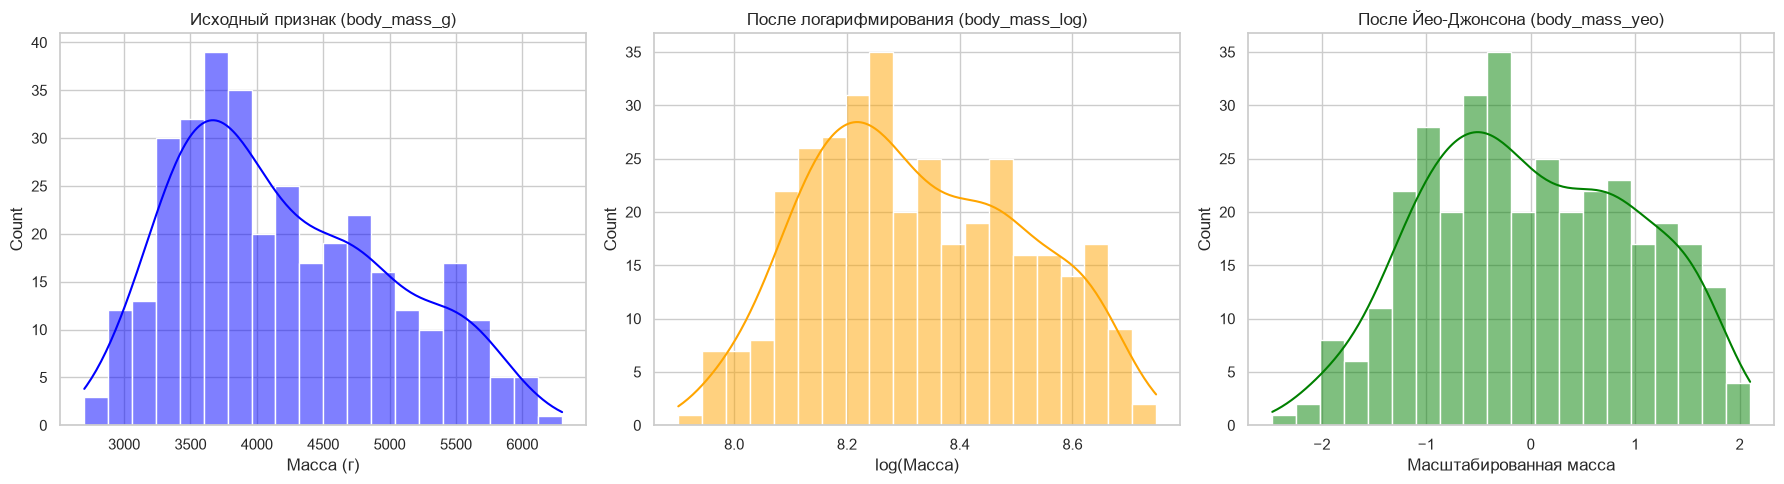

In [7]:
# Построим графики распределений до и после преобразований
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Исходное распределение массы тела
sns.histplot(df['body_mass_g'], bins=20, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Исходный признак (body_mass_g)', fontsize=12)
axes[0].set_xlabel('Масса (г)')

# После логарифмирования
sns.histplot(df['body_mass_log'], bins=20, kde=True, ax=axes[1], color='orange')
axes[1].set_title('После логарифмирования (body_mass_log)', fontsize=12)
axes[1].set_xlabel('log(Масса)')

# После преобразования Йео-Джонсона
sns.histplot(df['body_mass_yeo'], bins=20, kde=True, ax=axes[2], color='green')
axes[2].set_title('После Йео-Джонсона (body_mass_yeo)', fontsize=12)
axes[2].set_xlabel('Масштабированная масса')

plt.tight_layout()
plt.show()

### Выводы по лабораторной работе

В результате выполнения лабораторной работы были изучены и применены на практике методы предобработки данных на примере датасета «Penguins»:

1. **Обработка пропусков:** С помощью класса `SimpleImputer` устранены пропуски в данных. Числовые признаки заполнены медианными значениями (что защищает от влияния выбросов), а категориальный признак пола (`sex`) заполнен модой (наиболее часто встречающимся значением).
2. **Кодирование категориальных признаков:** Выполнено кодирование признаков с использованием `LabelEncoder` (для бинарного признака пола) и `OneHotEncoder` (для номинального признака острова). Это позволило представить качественные данные в виде векторов чисел, пригодных для обучения ML-моделей.
3. **Нормализация признаков:** Было исследовано влияние логарифмического преобразования и метода Йео-Джонсона на числовой признак массы тела. Преобразование Йео-Джонсона успешно центрировало распределение и приблизило его форму к стандартной нормальной кривой.